In [11]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [12]:
# === Load the Drug–ADR matrix ===
matrix = np.loadtxt("final_preds.txt")
matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1177, 4247))

In [13]:
# Each row = drug, each column = ADR
n_drugs, n_adrs = matrix.shape
print(f"Matrix shape: {n_drugs} drugs × {n_adrs} ADRs")

Matrix shape: 1177 drugs × 4247 ADRs


In [14]:
# === Compute ADR counts per drug ===
adr_counts = matrix.sum(axis=1)  # number of 1's per drug
adr_counts

array([151., 160., 377., ...,  97.,  25.,  45.], shape=(1177,))

In [18]:
adr_counts.mean()

np.float64(165.8555649957519)

In [19]:
adr_counts.min()

np.float64(3.0)

In [20]:
adr_counts.max()

np.float64(604.0)

In [15]:
# === Load mapping for labels (optional, for debugging or tooltips) ===
with open("../../../dataset/final_dataset1/drug2id.json") as f:
    drug2id = json.load(f)
id2drug = {v: k for k, v in drug2id.items()}

In [16]:
# === Sort to show head–tail behavior ===
adr_counts_sorted = np.sort(adr_counts)[::-1]

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

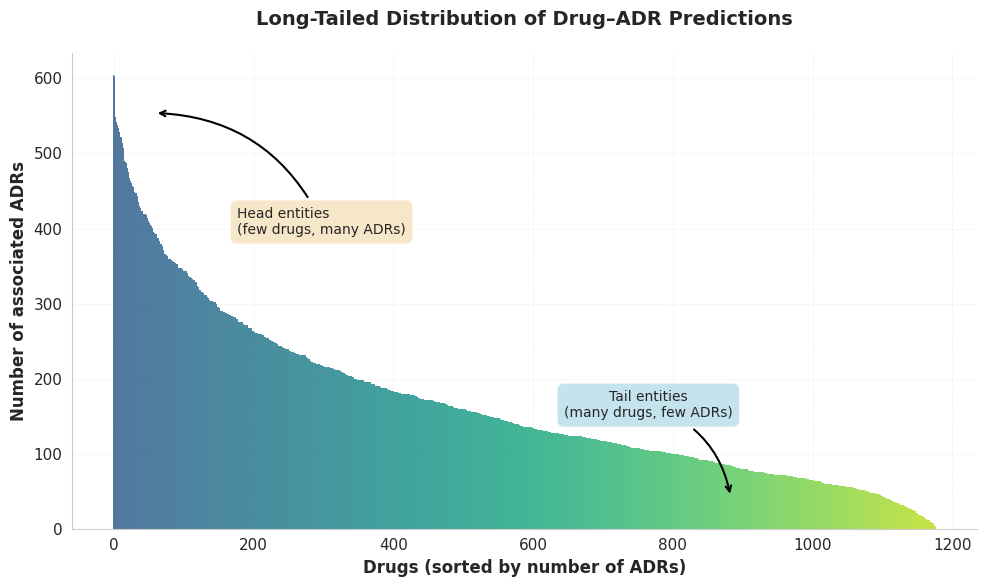

In [17]:
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 11

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 6))

# Create gradient color effect
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(adr_counts_sorted)))

# Plot with gradient
bars = ax.bar(range(len(adr_counts_sorted)), adr_counts_sorted, 
              color=colors, width=1.0, edgecolor='none', alpha=0.85)

# Styling
ax.set_xlabel("Drugs (sorted by number of ADRs)", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of associated ADRs", fontsize=12, fontweight='bold')
ax.set_title("Long-Tailed Distribution of Drug–ADR Predictions", 
             fontsize=14, fontweight='bold', pad=20)

# Grid styling
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotations with better positioning and styling
head_y = adr_counts_sorted[0] * 0.65
tail_y = max(adr_counts_sorted[-1] + 55, adr_counts_sorted.max() * 0.05)

# Head annotation with arrow
ax.annotate('Head entities\n(few drugs, many ADRs)', 
            xy=(len(adr_counts_sorted) * 0.05, adr_counts_sorted[0] - 50), 
            xytext=(len(adr_counts_sorted) * 0.15, head_y),
            fontsize=10, ha='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', 
                          color='black', lw=1.5))

# Tail annotation with arrow
ax.annotate('Tail entities\n(many drugs, few ADRs)', 
            xy=(len(adr_counts_sorted) * 0.75, adr_counts_sorted[-1] + 40), 
            xytext=(len(adr_counts_sorted) * 0.65, tail_y + adr_counts_sorted.max() * 0.15),
            fontsize=10, ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', 
                          color='black', lw=1.5))

plt.tight_layout()
plt.savefig("adr_longtail_distribution.pdf", dpi=300, bbox_inches='tight')
plt.show()